# Magnetic levitation / eddy-current braking (radia.levitation) -- showcase

Consolidated view of the `radia.levitation` (maglev / ECB) example tier: the **mixed-Galerkin polarizability `alpha(s)`** core, validated **sphere** levitation force, **shape-anisotropic** ellipsoid tensor, the **moving-magnet magnetic-Reynolds (`Rm`) crossover**, and the **TEAM 28** electrodynamic-levitation benchmark. Method: **Radia IEM (open-boundary analytic field) + NGSolve reduced-potential eddy FEM**, weak-coupled -- magnet motion needs only a field update, no re-meshing (see `radia_mcp.maglev`).

The committed result figures are shown below (golden-locked corpus; not re-solved here). Knowledge: `radia_mcp.maglev` (`radia_iem_fem`, `cln_mor_control`).

*Corpus kept at `docs/maglev/demos/` (golden tests; `research_cln/` + `papers/` are separate); this is the rendered showcase.*

## Result gallery (committed)

**Mixed-Galerkin polarizability `alpha(s)` sweep** (Cu cube) -- the headline package API: Re = flux exclusion, |Im| = eddy loss, CAD-direct edges vs mesh-derived.

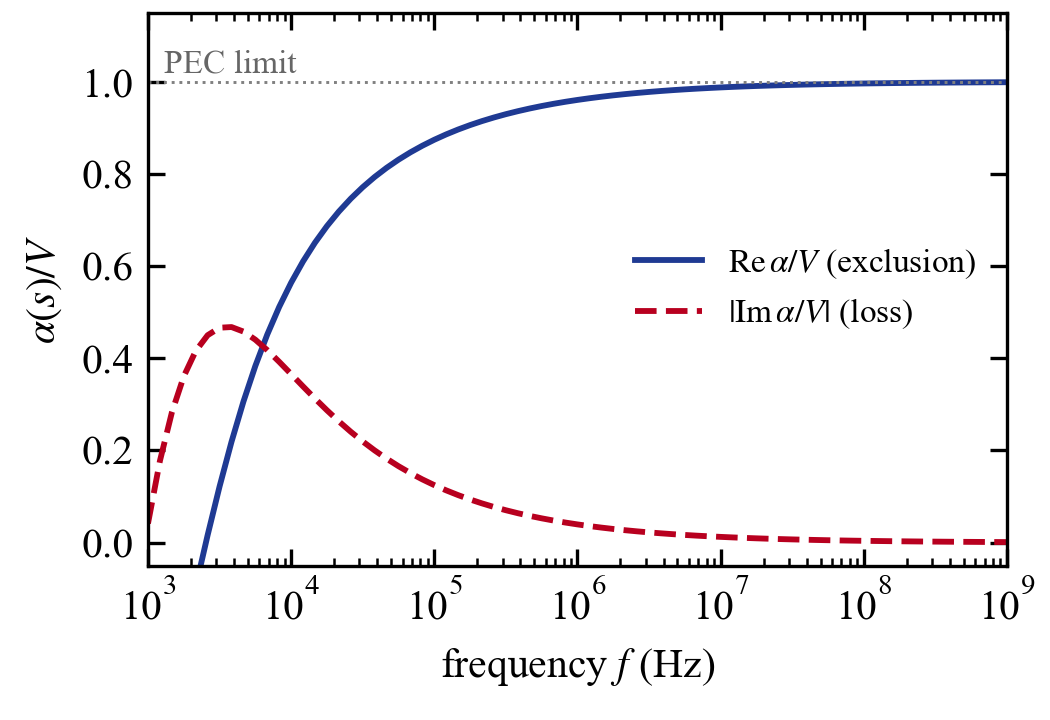

In [1]:
from IPython.display import Image, display
display(Image('demos/cube_alpha_sweep.png'))

**Sphere levitation force vs frequency** -- analytic dipole + eddy FEM + Maxwell-stress cross-check.

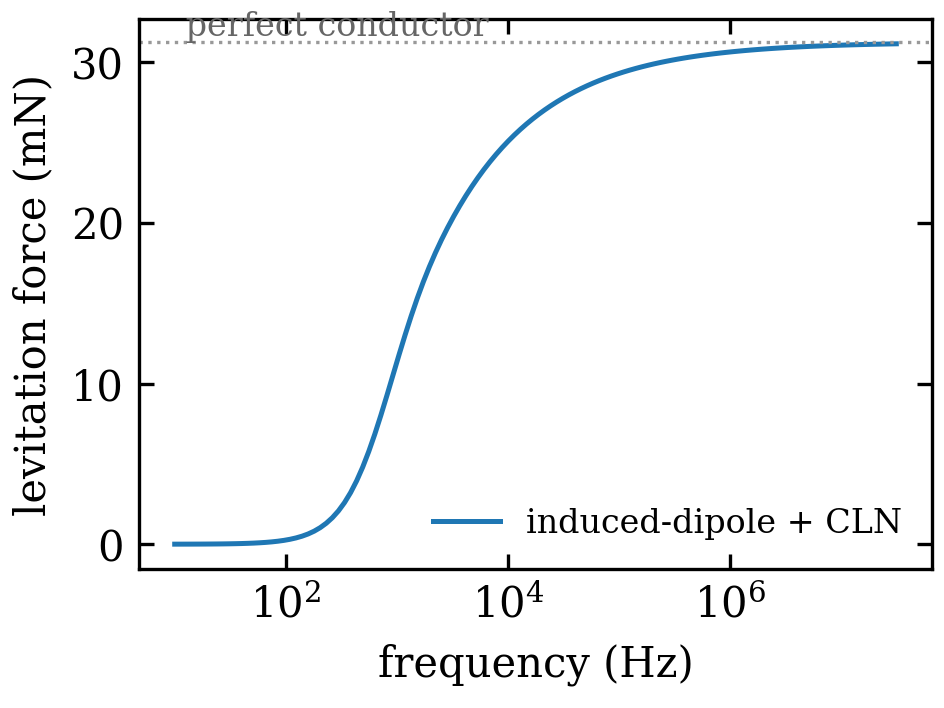

In [2]:
from IPython.display import Image, display
display(Image('demos/sphere/maglev_sphere_force_vs_freq.png'))

**Coil + conducting sphere eddy-current force** (validated workflow).

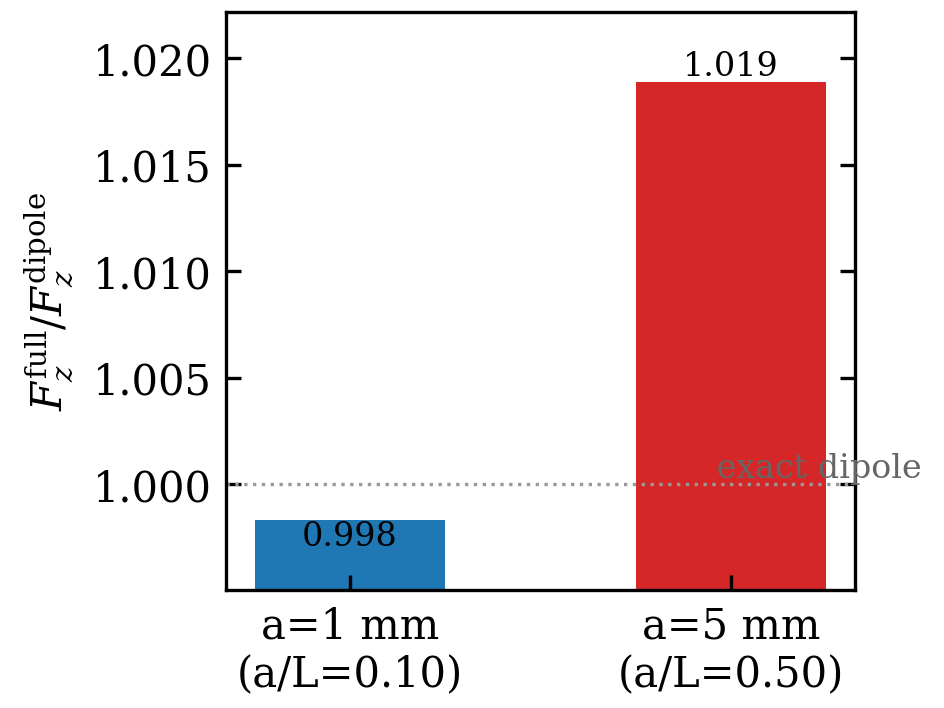

In [3]:
from IPython.display import Image, display
display(Image('demos/sphere/coil_sphere_eddy_force.png'))

**Coil-levitation equilibrium** (force balance vs height).

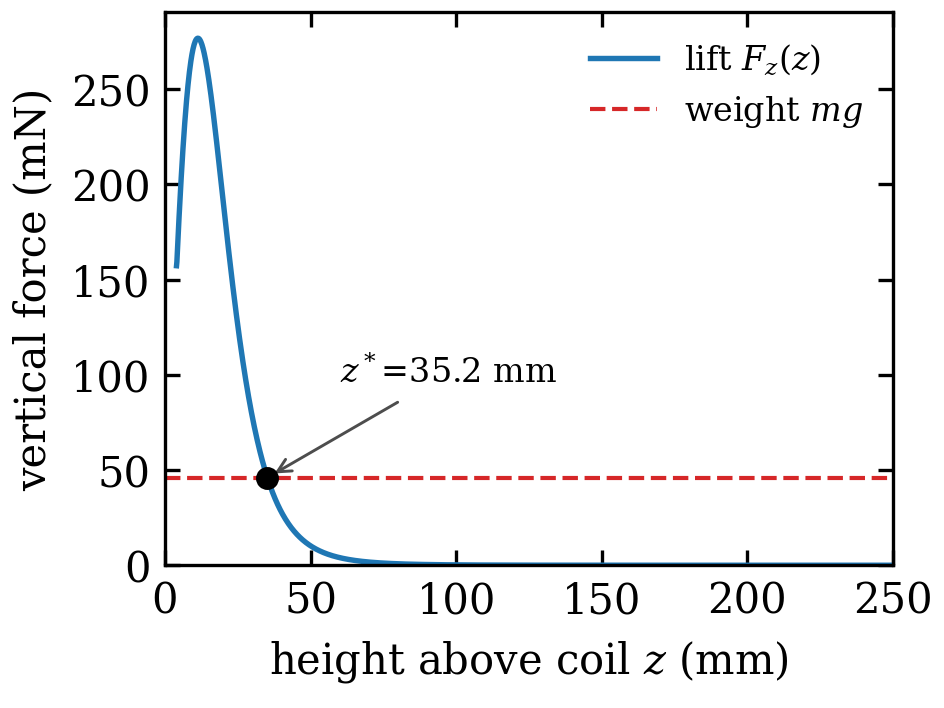

In [4]:
from IPython.display import Image, display
display(Image('demos/sphere/coil_maglev_equilibrium.png'))

**Shape-anisotropic polarizability `alpha(omega)`** (axisymmetric ellipsoid): DC + HF anchors + FEM.

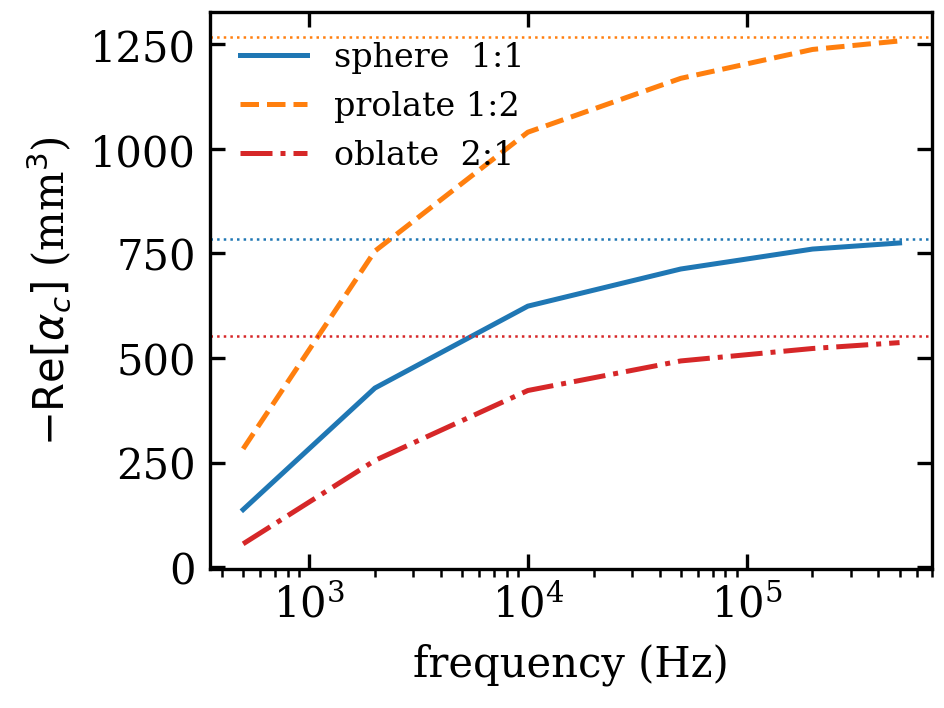

In [5]:
from IPython.display import Image, display
display(Image('demos/ellipsoid/ellipsoid_alpha_omega_axisym.png'))

**Triaxial-ellipsoid polarizability tensor** -- per-axis lift/drag anisotropy.

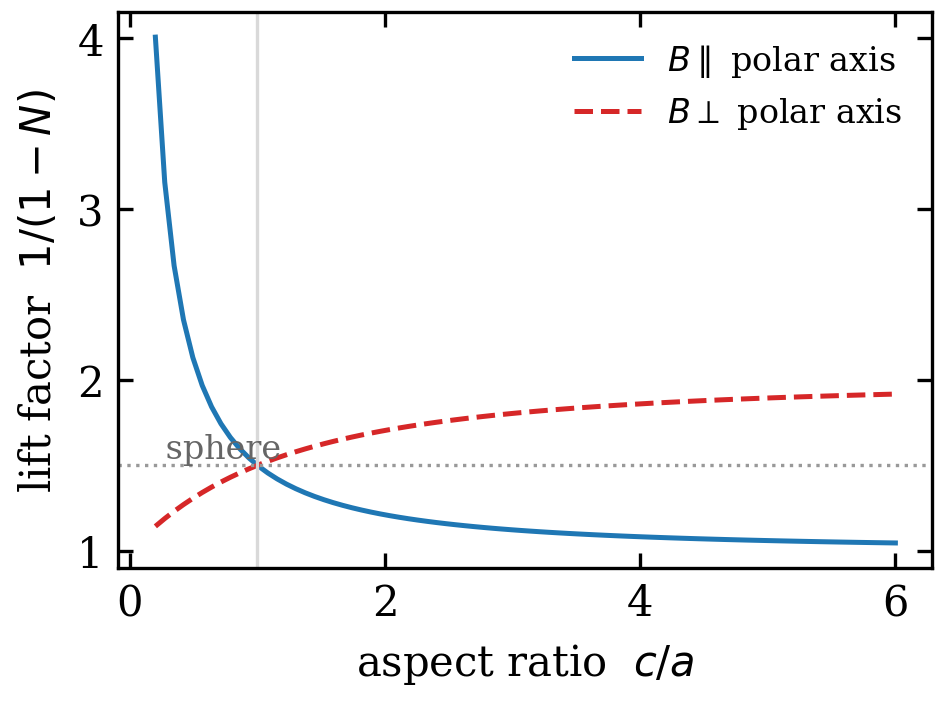

In [6]:
from IPython.display import Image, display
display(Image('demos/ellipsoid/ellipsoid_alpha_tensor_lift.png'))

**Moving-magnet eddy current + magnetic-Reynolds `Rm` crossover** (Yano's rotating-PM-over-plate): source-only kinematic vs full-FEM vs constant-basis CLN; source-only error grows with Rm.

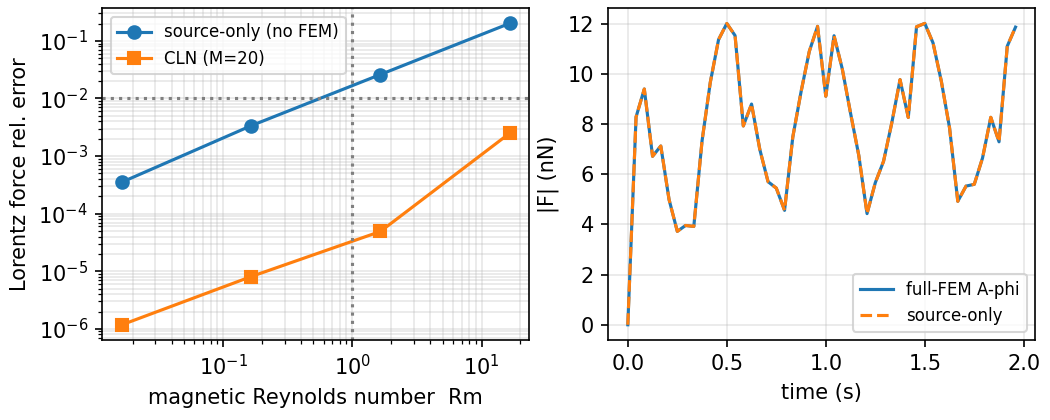

In [7]:
from IPython.display import Image, display
display(Image('demos/rotating_magnet_eddy.png'))

**TEAM Problem 28** electrodynamic levitation: full-FEM baseline + CLN force-vs-height.

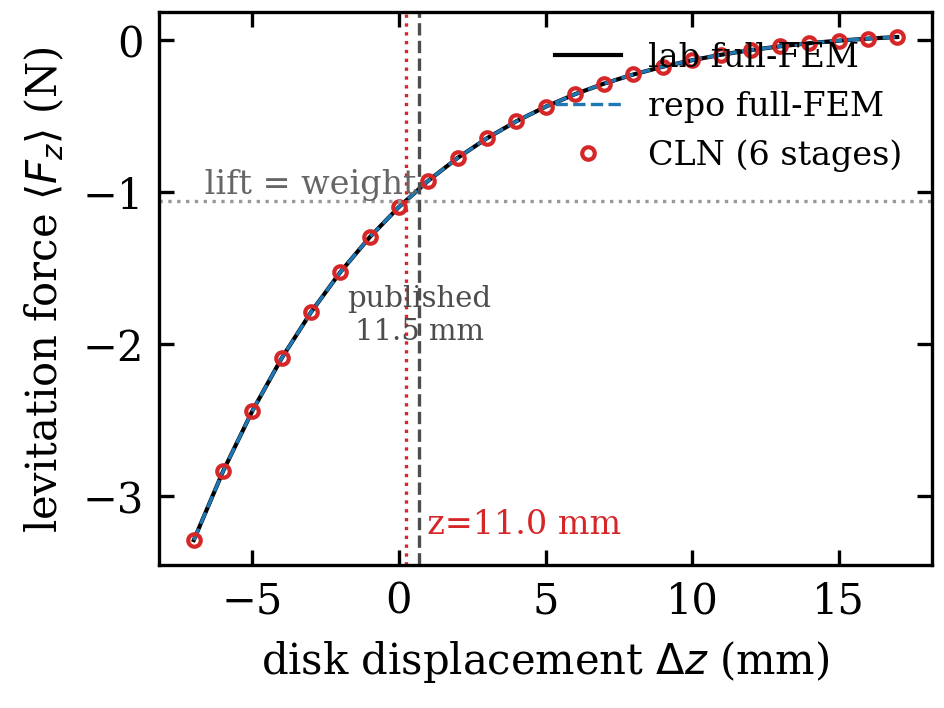

In [8]:
from IPython.display import Image, display
display(Image('demos/team28/team28_cln_force_vs_height.png'))

## Headline numbers (from committed result JSON)

In [9]:

import json, os
REL = os.path.join("..", "..", "validation_test", "maglev", "demos")

def show(fn, summaries):
    p = os.path.join(REL, fn)
    if not os.path.isfile(p):
        print(f"(missing {fn})"); return
    d = json.load(open(p))
    print(f"--- {fn} ---")
    for label, extract in summaries:
        print(f"  {label}: {extract(d)}")
    print()

# Headline numbers from durable validation records (no re-solve).
show("cube_alpha_sweep_results.json", [
    ("frequency points", lambda d: len(d["f_hz"])),
    ("high-frequency Re(alpha)/V", lambda d: f'{d["re_alpha_over_V"][-1]:.6f}'),
])
show("rotating_magnet_eddy_results.json", [
    ("Rm range", lambda d: f'{d["rows"][0]["Rm"]:.3g} to {d["rows"][-1]["Rm"]:.3g}'),
    ("source-only force error range", lambda d: f'{d["rows"][0]["source_only_F_err"]:.3g} to {d["rows"][-1]["source_only_F_err"]:.3g}'),
])
show("team28/team28_cln_sweep_results.json", [
    ("CLN equilibrium height (mm)", lambda d: f'{d["equilibrium_abs_height_mm"]["cln"]:.3f}'),
    ("max |CLN-lab| (N)", lambda d: f'{d["max_abs_cln_minus_lab_N"]:.3e}'),
])
show("sphere/maglev_sphere_force_results.json", [
    ("frequency points", lambda d: len(d["freq_Hz"])),
    ("high-frequency lift / PEC", lambda d: f'{d["lift_N"][-1] / d["perfect_conductor_lift_N"]:.6f}'),
])


--- cube_alpha_sweep_results.json ---
  frequency points: 73
  high-frequency Re(alpha)/V: 0.998746

--- rotating_magnet_eddy_results.json ---
  Rm range: 0.0165 to 16.5
  source-only force error range: 0.000352 to 0.201

--- team28/team28_cln_sweep_results.json ---
  CLN equilibrium height (mm): 11.039
  max |CLN-lab| (N): 4.657e-04

--- sphere/maglev_sphere_force_results.json ---
  frequency points: 120
  high-frequency lift / PEC: 0.996474

